In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import yaml

project_root  = Path.cwd().resolve().parent.parent
processed_dir = project_root / 'src' / 'data' / 'processed'
models_dir = project_root / 'src' / 'evaluation'
baseline_dir = project_root / 'src' / 'baseline'

with open(project_root / 'src' / 'config.yaml') as f:
    config = yaml.safe_load(f)

figures_dir = project_root / 'src' / 'evaluation' / config['paths']['model_filename']
figures_dir.mkdir(exist_ok=True)

# Load experiment summary
with open(models_dir / 'experiment_summary.json') as f:
    experiments = json.load(f)

# Load baseline results
with open(baseline_dir / 'baseline.json') as f:
    baseline = json.load(f)

summary_df = pd.DataFrame(experiments)
print(summary_df[['experiment', 'architecture', 'accuracy', 'uq_low_acc', 'uq_high_acc']])

plt.style.use('default')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.8,
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
})

    experiment             architecture  accuracy  uq_low_acc  uq_high_acc
0  test_Net_16    PitStrategyNetWithVal  0.527990    0.653846     0.460674
1  test_Net_17    PitStrategyNetWithVal  0.531807    0.619231     0.464419
2  test_Net_18    PitStrategyNetWithVal  0.524173    0.611538     0.430712
3  test_Net_19    PitStrategyNetWithVal  0.516539    0.619231     0.471910
4  test_Net_20    PitStrategyNetWithVal  0.521628    0.623077     0.449438
5  test_Net_21    PitStrategyNetWithVal  0.538168    0.623077     0.494382
6  test_Net_22    PitStrategyNetWithVal  0.534351    0.638462     0.453184
7   test_GRU_1  PitStrategyGRUAttention  0.449931    0.506224     0.395161


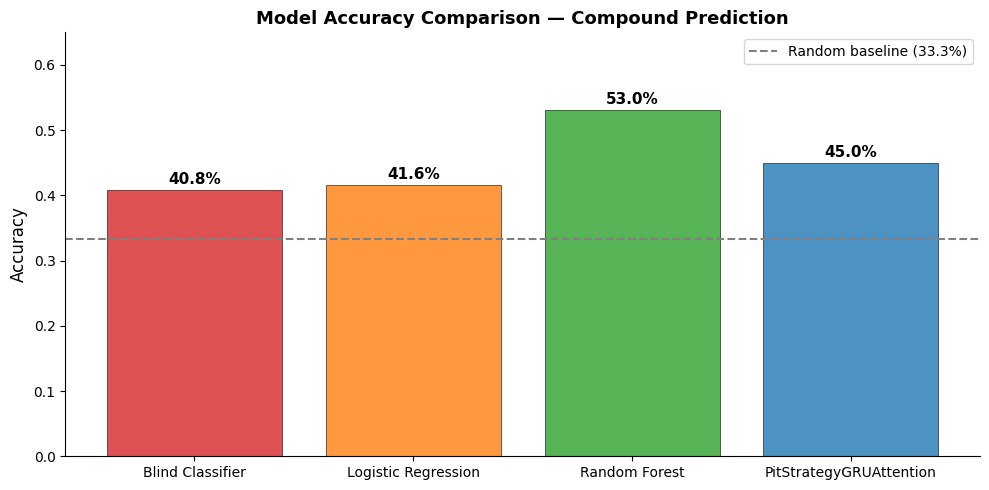

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

summary_current = summary_df.iloc[-1] # Get the latest model summary
models = ['Blind Classifier', 'Logistic Regression', 'Random Forest', summary_current['architecture']]
accuracies = [0.4084, 0.4160, 0.5305, summary_current['accuracy']]
colours = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

bars = ax.bar(models, accuracies, color=colours, alpha=0.8, edgecolor='black', linewidth=0.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Add random baseline line
ax.axhline(y=0.333, color='grey', linestyle='--', linewidth=1.5, label='Random baseline (33.3%)')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Accuracy Comparison — Compound Prediction', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.65)
ax.legend()
ax.yaxis.grid(False)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(figures_dir / 'model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

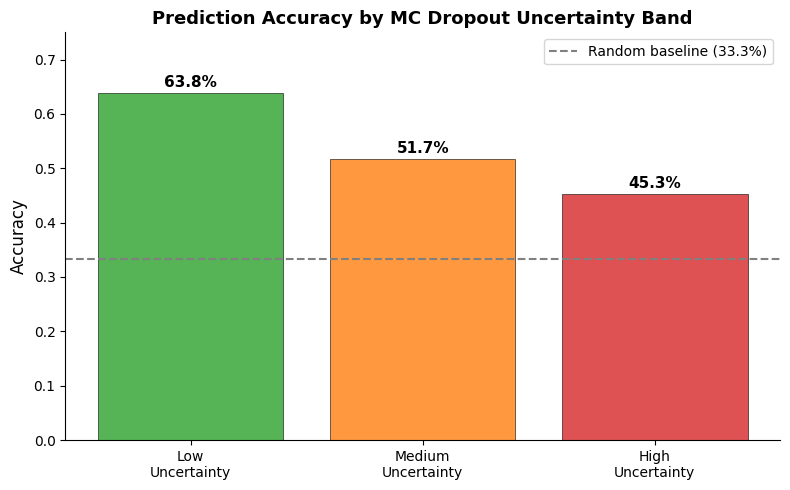

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

bands = ['Low\nUncertainty', 'Medium\nUncertainty', 'High\nUncertainty']
accuracy = [summary_current['uq_low_acc'], summary_current['uq_med_acc'], summary_current['uq_high_acc']]

colours = ['#2ca02c', '#ff7f0e', '#d62728']

bars = ax.bar(bands, accuracy, color=colours, alpha=0.8, edgecolor='black', linewidth=0.5)

for bar, acc in zip(bars, accuracy):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.axhline(y=0.333, color='grey', linestyle='--', linewidth=1.5, label='Random baseline (33.3%)')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Prediction Accuracy by MC Dropout Uncertainty Band', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.75)
ax.legend()
ax.yaxis.grid(False)
ax.xaxis.grid(False)

plt.tight_layout()
plt.savefig(figures_dir / 'uq_across_experiments.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

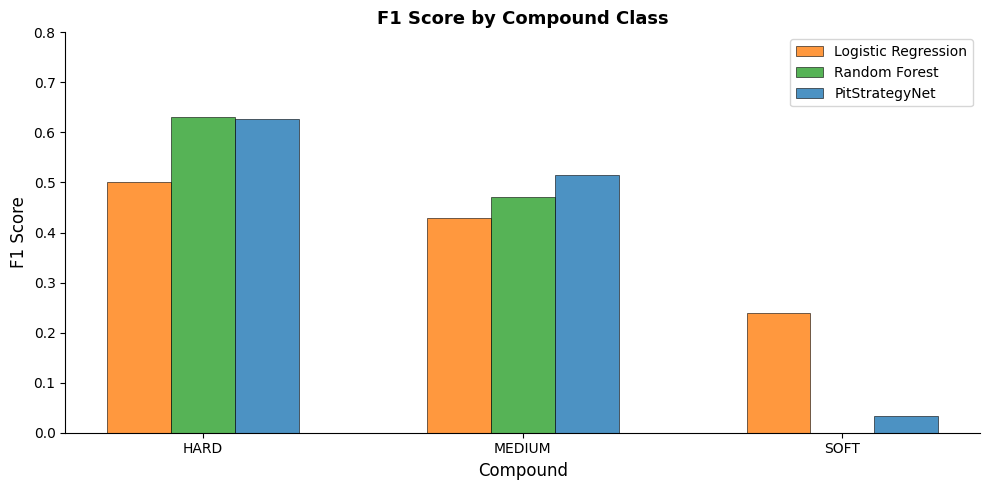

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(3)
width = 0.2
classes = ['HARD', 'MEDIUM', 'SOFT']

models_f1 = {
    'Logistic Regression': [0.50, 0.43, 0.24],
    'Random Forest': [0.63, 0.47, 0.00],
    summary_current['architecture']: [summary_current['hard_f1'], summary_current['medium_f1'], summary_current['soft_f1']],
}

colours = ['#ff7f0e', '#2ca02c', '#1f77b4']

for i, (model, f1s) in enumerate(models_f1.items()):
    bars = ax.bar(x + i*width, f1s, width, label=model,
                  color=colours[i], alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Compound', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score by Compound Class', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(classes)
ax.legend()
ax.yaxis.grid(False)
ax.xaxis.grid(False)
ax.set_ylim(0, 0.8)

plt.tight_layout()
plt.savefig(figures_dir / 'f1_by_class.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

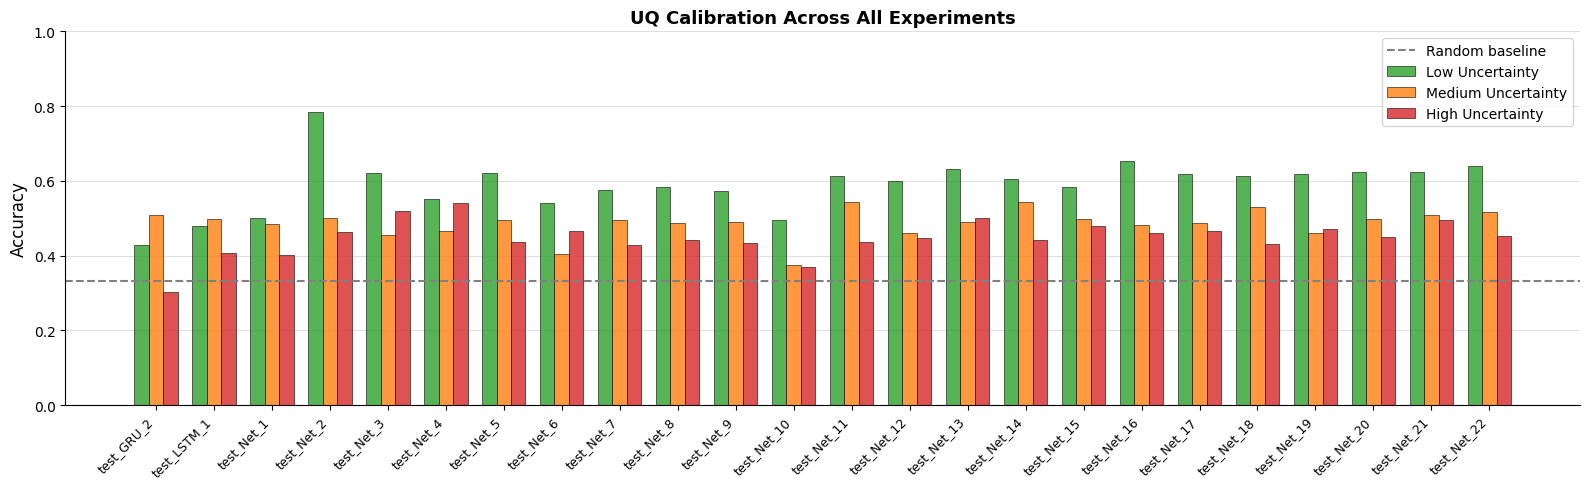

In [38]:
fig, ax = plt.subplots(figsize=(16, 5), facecolor='white')
ax.set_facecolor('white')

exp_names = [e['experiment'] for e in experiments if 'uq_low_acc' in e and 'uq_med_acc' in e and 'uq_high_acc' in e]
low_accs = [e['uq_low_acc']  for e in experiments if 'uq_low_acc' in e and 'uq_med_acc' in e and 'uq_high_acc' in e]
med_accs = [e['uq_med_acc']  for e in experiments if 'uq_low_acc' in e and 'uq_med_acc' in e and 'uq_high_acc' in e]
high_accs = [e['uq_high_acc'] for e in experiments if 'uq_low_acc' in e and 'uq_med_acc' in e and 'uq_high_acc' in e]

x = np.arange(len(exp_names))
width = 0.25  # narrower to fit three bars

ax.bar(x - width, low_accs, width, label='Low Uncertainty', color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.bar(x, med_accs, width, label='Medium Uncertainty', color='#ff7f0e', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.bar(x + width, high_accs, width, label='High Uncertainty', color='#d62728', alpha=0.8, edgecolor='black', linewidth=0.5)

ax.axhline(y=0.333, color='grey', linestyle='--', linewidth=1.5, label='Random baseline')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('UQ Calibration Across All Experiments', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(exp_names, rotation=45, ha='right', fontsize=9)
ax.legend()
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(figures_dir / 'uq_across_experiments.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

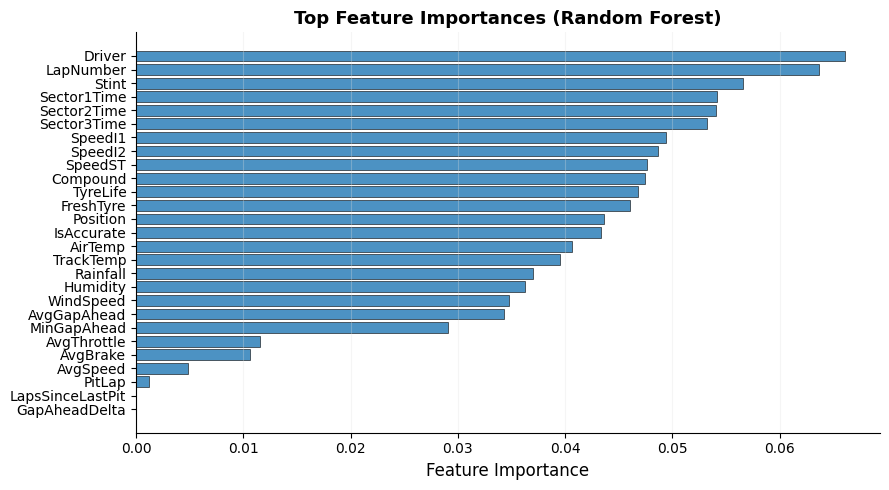

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))

features = list(baseline['feature_importance'].keys())
values = list(sorted(baseline['feature_importance'].values(), reverse=True))

bars = ax.barh(features[::-1], values[::-1], color='#1f77b4', alpha=0.8,
               edgecolor='black', linewidth=0.5)

ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Top Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()